# Week 1 — Task 3: Distributions and relationships

**Dataset:** `data/penguins.csv` — 344 penguins, 3 species, 3 islands. Columns: `species`, `island`,
`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`, `sex`.

> Run `python3 download_assignment_data.py` first, and run this notebook from the `assignments/` folder.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (same as the lecture) ---------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]

# Ink + surface colours. Text is NEVER the colour of the data.
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

# ---- House style ---------------------------------------------------
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    # Save every chart to charts/ so it can be dropped into slides.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)


def footnote(ax, text, y=-0.2):
    # One-line note under a chart: exclusions, sample sizes, caveats.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


## 1. Find the missing values first, as the brief asks

In [2]:
p = pd.read_csv(DATA / "penguins.csv")
print("Rows:", p.shape[0])
missing = p.isna().sum()
print(missing[missing > 0])
print()
print("Rows missing ALL four measurements:")
print(p[p["bill_length_mm"].isna()][["species", "island", "sex"]])
print()
print("Rows missing sex only, by species:")
print(p[p["sex"].isna() & p["body_mass_g"].notna()]["species"].value_counts())

Rows: 344
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Rows missing ALL four measurements:
    species     island  sex
3    Adelie  Torgersen  NaN
339  Gentoo     Biscoe  NaN

Rows missing sex only, by species:
species
Adelie    5
Gentoo    4
Name: count, dtype: int64


**My decision, stated up front:**

- **2 penguins are missing all four measurements** (body mass, both bills, flipper length) — they carry
  no usable information for any chart in this notebook, so I **drop them**. That leaves **342 penguins**
  for every chart that does not involve `sex`.
- **11 penguins are missing `sex`** (5 Adelie, 4 Gentoo, 2 more among the all-missing rows) but have every
  other measurement. I **keep them** for charts that do not need sex, and **exclude them only from the
  one chart that groups by sex** (Section 4), where I say so on the chart.

I will state the sample size on every chart, so nobody has to guess which rows were used.

In [3]:
df = p.dropna(subset=["body_mass_g"]).copy()   # the 2 fully-empty rows are gone from here on
print("Working sample:", len(df), "penguins")

Working sample: 342 penguins


## 2. Step 1 — the distribution of body mass

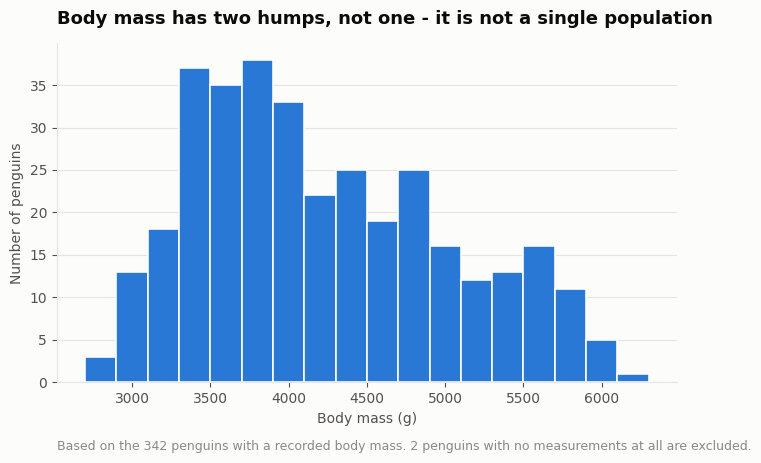

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.4))

ax.hist(df["body_mass_g"], bins=np.arange(2700, 6500, 200), color=BLUE,
        edgecolor=SURFACE, linewidth=1.2, zorder=3)

ax.set_title("Body mass has two humps, not one - it is not a single population")
ax.set_xlabel("Body mass (g)")
ax.set_ylabel("Number of penguins")
ax.xaxis.grid(False)
ax.set_axisbelow(True)
footnote(ax, f"Based on the {len(df)} penguins with a recorded body mass. 2 penguins with no measurements at all are excluded.")

save(fig, "t3_mass_histogram")
plt.show()

**Why a histogram?** The question is about the **shape** of one continuous variable, and a histogram is
the only chart built for that — bars touch because there is no real gap between "4,000g" and "4,001g".

**What shape is it?** It is **not** a single symmetric hump. There is a broad peak around 3,300–3,900g,
a dip around 4,300–4,700g, and a second, smaller bump around 5,000–5,700g. That is a sign of a
**bimodal** — or really multi-group — distribution: the data is a mix of more than one underlying
population, plotted as if it were one.

## 3. Step 2 — redraw split by species

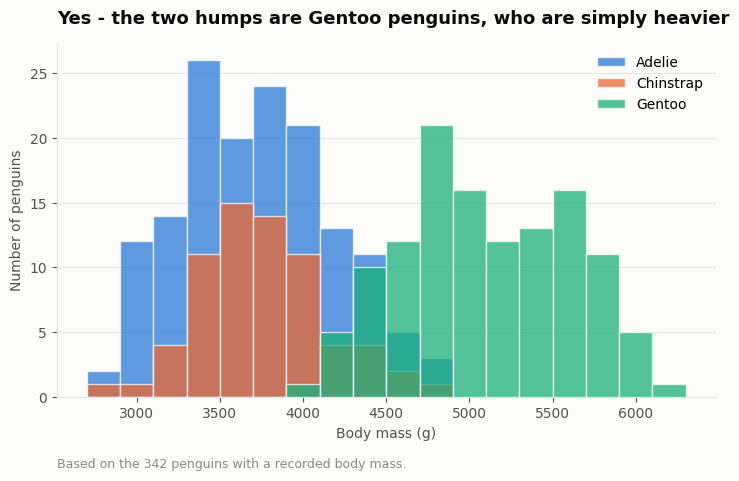

In [5]:
SPECIES = {"Adelie": BLUE, "Chinstrap": ORANGE, "Gentoo": AQUA}
bins = np.arange(2700, 6500, 200)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
for name, colour in SPECIES.items():
    ax.hist(df.loc[df["species"] == name, "body_mass_g"], bins=bins, color=colour,
            alpha=0.75, edgecolor=SURFACE, linewidth=1, label=name, zorder=3)

ax.set_title("Yes - the two humps are Gentoo penguins, who are simply heavier")
ax.set_xlabel("Body mass (g)")
ax.set_ylabel("Number of penguins")
ax.legend(loc="upper right")
ax.xaxis.grid(False)
ax.set_axisbelow(True)
footnote(ax, f"Based on the {len(df)} penguins with a recorded body mass.")

save(fig, "t3_mass_by_species")
plt.show()

In [6]:
df.groupby("species")["body_mass_g"].agg(n="size", mean="mean", std="std").round(0)

,n,mean,std
species,,,
Adelie,151,3701.0,459.0
Chinstrap,68,3733.0,384.0
Gentoo,123,5076.0,504.0


**Does this explain the shape from Step 1? Yes, completely.** Adelie (mean ≈ 3,700g) and Chinstrap
(mean ≈ 3,730g) overlap almost entirely and together form the left hump. **Gentoo penguins are a genuinely
different, heavier group** (mean ≈ 5,076g — about 1,350g more), and they alone form the right hump. The
"two humps" in the combined histogram were never a strange feature of body mass in general; they were
**three species being plotted as if they were one population.** Overlapping histograms (rather than a
single stacked one) are the right choice here because I want to compare *shapes*, and each is
semi-transparent so the overlap between Adelie and Chinstrap stays visible.

## 4. Step 3 — bill length vs bill depth, coloured by species (Simpson's paradox)

In [7]:
overall_r = df["bill_length_mm"].corr(df["bill_depth_mm"])
by_species_r = df.groupby("species").apply(
    lambda g: g["bill_length_mm"].corr(g["bill_depth_mm"]), include_groups=False
)
print("Correlation across ALL penguins pooled together:", round(overall_r, 3))
print("Correlation WITHIN each species:")
print(by_species_r.round(3))

Correlation across ALL penguins pooled together: -0.235
Correlation WITHIN each species:
species
Adelie       0.391
Chinstrap    0.654
Gentoo       0.643
dtype: float64


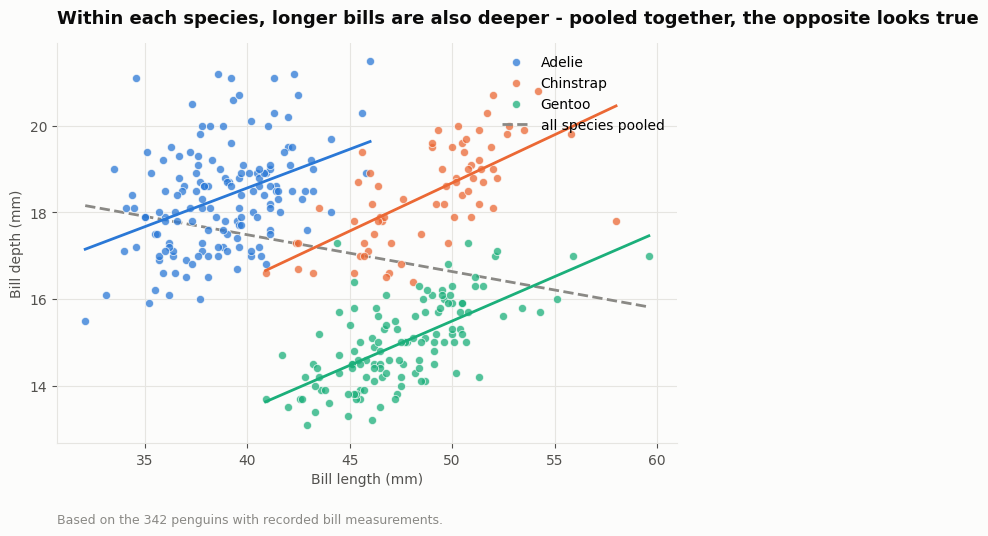

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.2))

for name, colour in SPECIES.items():
    g = df[df["species"] == name]
    ax.scatter(g["bill_length_mm"], g["bill_depth_mm"], s=34, color=colour, alpha=0.75,
               edgecolor=SURFACE, linewidth=0.6, label=name, zorder=3)
    slope, intercept = np.polyfit(g["bill_length_mm"], g["bill_depth_mm"], 1)
    xs = np.array([g["bill_length_mm"].min(), g["bill_length_mm"].max()])
    ax.plot(xs, slope * xs + intercept, color=colour, linewidth=2, zorder=4)

# The misleading pooled trend, in dashed grey, for contrast.
slope, intercept = np.polyfit(df["bill_length_mm"], df["bill_depth_mm"], 1)
xs = np.array([df["bill_length_mm"].min(), df["bill_length_mm"].max()])
ax.plot(xs, slope * xs + intercept, color=INK_MUTED, linewidth=2, linestyle="--", zorder=2,
        label="all species pooled")

ax.set_title("Within each species, longer bills are also deeper - pooled together, the opposite looks true")
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
ax.legend(loc="upper right")
footnote(ax, f"Based on the {len(df)} penguins with recorded bill measurements.")

save(fig, "t3_simpsons_paradox")
plt.show()

**What is going on.** Pooled across all 342 penguins, bill length and bill depth look **negatively**
related (r ≈ −0.23, the dashed grey line slopes down): longer bills seem to go with shallower ones. But
**within every single species** the relationship is **positive** (r ≈ 0.39 for Adelie, 0.65 for
Chinstrap, 0.64 for Gentoo — all three solid lines slope up). Both statements are numerically true; they
are answers to different questions.

The trick is that **species is a confounding variable**: Gentoo penguins happen to have long bills that
are also comparatively *shallow* for their length, while occupying a different region of the plot from
Adelie and Chinstrap. So the three species form three diagonal clouds arranged so that the cloud
*positions* run one way even though every cloud individually runs the other way. Pool them and you fit a
line through three separated groups instead of through the actual relationship inside any one group. This
is **Simpson's paradox**: a trend that appears in the combined data reverses, or disappears, once the
data is split by the group that was driving it.

**Why a scatter plot, and why colour by species?** Two numeric variables, so a scatter is the only chart
that shows every point's exact position on both. Colour here carries real information (species), which is
the only reason to use it, and it is precisely what reveals the paradox — without the colours this plot
is just a formless negative-looking cloud.

## 5. Step 4 — average body mass by species and sex

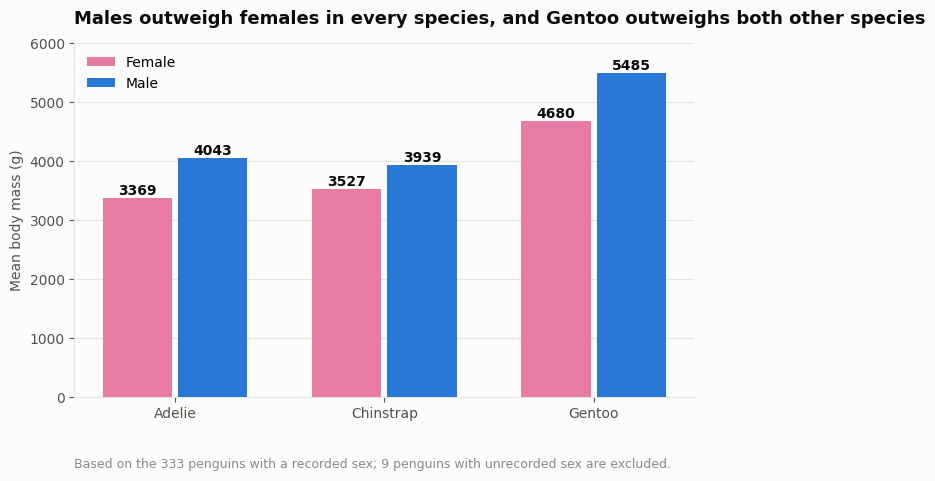

In [9]:
sexed = df.dropna(subset=["sex"]).copy()
sexed["sex"] = sexed["sex"].str.capitalize()
n_excluded = len(df) - len(sexed)

by_ss = sexed.groupby(["species", "sex"])["body_mass_g"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 4.6))
species_order = ["Adelie", "Chinstrap", "Gentoo"]
x = np.arange(len(species_order))
width = 0.36

for i, (sex, colour) in enumerate(zip(["Female", "Male"], [MAGENTA, BLUE])):
    values = by_ss.loc[species_order, sex]
    bars = ax.bar(x + (i - 0.5) * width, values, width=width * 0.92, color=colour, label=sex, zorder=3)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 60, f"{v:.0f}", ha="center",
                fontsize=10, fontweight="bold", color=INK)

ax.set_xticks(x)
ax.set_xticklabels(species_order)
ax.set_title("Males outweigh females in every species, and Gentoo outweighs both other species")
ax.set_ylabel("Mean body mass (g)")
ax.set_ylim(0, 6000)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.legend(loc="upper left")
footnote(ax, f"Based on the {len(sexed)} penguins with a recorded sex; {n_excluded} penguins with unrecorded sex are excluded.")

save(fig, "t3_mass_by_species_sex")
plt.show()

**Why a grouped bar chart?** This compares averages across **two categorical dimensions** at once
(species and sex) — exactly the case for a grouped bar. I grouped the bars **by species**, because the
comparison I want the reader to make side-by-side is male-vs-female *within* a species, not species-vs-species
within a sex.

Both effects are real: **sex** matters (males are heavier than females in every one of the three species,
by roughly 550–800g), and **species** matters more (even Gentoo females, at about 4,680g, outweigh Adelie
and Chinstrap males). Neither variable alone would have told the full story — which is the same lesson as
Simpson's paradox above: always check whether a group you haven't split on is doing the real work.

## 6. Summary

| Chart | Type | What it showed |
|---|---|---|
| Mass, all penguins | Histogram | Two humps — a sign of a mixed population |
| Mass, by species | Overlapping histograms | The humps are just Gentoo vs the other two species |
| Bill length vs depth | Scatter, coloured by species | Simpson's paradox: negative pooled, positive within each group |
| Mass by species & sex | Grouped bar | Species and sex both matter; species matters more |